# ESN-Only Baseline

**Purpose:** Evaluate a reservoir (ESN) with a direct linear readout in closed-loop
forecast mode, without any HAVOK linear model identification.  
This isolates the contribution of the HAVOK stage in the RC-HAVOK pipeline.

## Scientific question
Does the HAVOK linear model identification stage add value beyond what the
reservoir alone provides for reconstructing Chua circuit dynamics?

## Architecture comparison
```
RC-HAVOK:  x(t) → Reservoir → s(t) → Hankel → SVD → A,B → free-run (HAVOK coords)
ESN-only:  x(t) → Reservoir → s(t) → Linear readout W_out → closed-loop x̂(t)
```

## Evaluation protocol
The ESN-only readout is operated in **closed-loop forecast mode**:
- Train W_out by ridge regression on reservoir states → x(t) (teacher-forced)
- Then switch to closed-loop: feed x̂(k) = W_out @ s(k) back as input at k+1
- Evaluate free-run R² and RMSE on the last 13 seconds (same window as RC-HAVOK)

ESN-only closed-loop is an autonomous raw-signal baseline: no ground-truth
input is used during evaluation, and no HAVOK linear modelling is applied.
Because RC-HAVOK uses the extracted forcing coordinate v_r and evaluates in
HAVOK temporal-mode coordinates, the comparison is complementary rather than
directly equivalent — it characterises whether the reservoir alone can sustain
autonomous forecasting without the HAVOK linear model.

## Design
- **10 ESN seeds** (seeds 0–9) — same seeds as RC-HAVOK ablation notebook
- **Both PWL and cubic Chua** evaluated
- **Same locked reservoir config** as all prior notebooks
- **Ridge regression** for W_out (avoids overfitting with λ=1e-6)
- Closed-loop forecast evaluated on last 13 seconds

## Locked parameters (DO NOT MODIFY)
```
Chua: alpha=9, beta=100/7, m0=-1/7, m1=2/7, IC=(0.1,0.2,0.1)
Reservoir: N=500, sr=0.9, conn=0.200, leakage=0.400
Evaluation: 13s closed-loop forecast, raw x(t) space
T_END=200s, dt=0.001
```

## Wording conventions
- 'bounded double-scroll-like trajectory' — not 'confirmed chaos'
- 'supports' / 'suggests' — not 'proves'
- 'closed-loop forecast R²' on raw x(t)
- Note coordinate-space difference vs RC-HAVOK in all comparisons

---
> **Restart kernel → Run All** reproduces all results.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.sparse import random as sparse_random
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from numpy.lib.stride_tricks import sliding_window_view
import time
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIGURATION  (locked — do not modify for reported results)
# ═══════════════════════════════════════════════════════════════════

# ── Trajectory ──────────────────────────────────────────────────────
T_END          = 200.0
DT             = 0.001
BURN_IN        = 2000           # reservoir washout steps (same as RC-HAVOK)
EVAL_SECONDS   = 13.0           # closed-loop forecast window
INPUT_SCALE    = 0.1
MAX_X_NORM     = 1e3            # divergence threshold on raw x̂(t)

# ── Chua parameters (sign-corrected) ────────────────────────────────
ALPHA, BETA    = 9.0, 100.0 / 7.0
M0, M1         = -1.0 / 7.0, 2.0 / 7.0
INIT_STATE     = [0.1, 0.2, 0.1]

# ── Locked baseline reservoir config ────────────────────────────────
N_RES          = 500
SPECTRAL_RADIUS= 0.9
CONNECTIVITY   = 0.200
LEAKAGE        = 0.400

# ── ESN readout ─────────────────────────────────────────────────────
RIDGE_ALPHA    = 1e-6           # ridge regularisation for W_out
N_SEEDS        = 10             # same seeds as RC-HAVOK ablation
SEEDS          = list(range(N_SEEDS))

# ── Train/test split ─────────────────────────────────────────────────
# Train readout on everything except last EVAL_SECONDS
# Evaluate closed-loop on last EVAL_SECONDS
N_EVAL         = int(EVAL_SECONDS / DT)  # 13,000 steps

SYSTEMS        = ['pwl', 'cubic']

# ── RC-HAVOK reference values (final accepted, 20-seed notebooks) ────
RC_HAVOK_REF = {
    'pwl':   dict(r2_mod_median=0.97366, r2_mod_mean=0.97255,
                  r2_mod_sd=0.00374, rmse_mod_median=3.44e-4,
                  r2_ori_mean=-0.97474),
    'cubic': dict(r2_mod_median=0.99918, r2_mod_mean=0.99918,
                  r2_mod_sd=0.000006, rmse_mod_median=5.0e-5,
                  r2_ori_mean=-0.53853),
}

print(f'T_END={T_END}s | DT={DT} | BURN_IN={BURN_IN} | EVAL={EVAL_SECONDS}s')
print(f'N_RES={N_RES} | sr={SPECTRAL_RADIUS} | conn={CONNECTIVITY} | lk={LEAKAGE}')
print(f'RIDGE_ALPHA={RIDGE_ALPHA} | N_SEEDS={N_SEEDS} | N_EVAL={N_EVAL:,}')
print(f'Chua: alpha={ALPHA}, beta={BETA:.4f}, m0={M0:.6f}, m1={M1:.6f}')

T_END=200.0s | DT=0.001 | BURN_IN=2000 | EVAL=13.0s
N_RES=500 | sr=0.9 | conn=0.2 | lk=0.4
RIDGE_ALPHA=1e-06 | N_SEEDS=10 | N_EVAL=13,000
Chua: alpha=9.0, beta=14.2857, m0=-0.142857, m1=0.285714


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — CHUA TRAJECTORY GENERATION
# ═══════════════════════════════════════════════════════════════════

def h_pwl(x):
    return M1*x + 0.5*(M0 - M1)*(np.abs(x + 1) - np.abs(x - 1))

def h_cubic(x):
    return x**3 / 16.0 - x / 6.0

def chua_rhs(t, s, h_func):
    x, y, z = s
    return [ALPHA*(y - h_func(x)), x - y + z, -BETA*y]

def generate_chua(system):
    h    = h_pwl if system == 'pwl' else h_cubic
    t_ev = np.arange(0.0, T_END, DT)
    sol  = solve_ivp(chua_rhs, [0.0, T_END], INIT_STATE,
                     t_eval=t_ev, args=(h,),
                     method='RK45', rtol=1e-9, atol=1e-9)
    if not sol.success:
        raise RuntimeError(f'{system} solve_ivp failed: {sol.message}')
    return sol.y[0]

print('Generating Chua trajectories (RK45, rtol=atol=1e-9)...')
SYS_DATA = {}
for sys in SYSTEMS:
    x = generate_chua(sys)
    SYS_DATA[sys] = x
    print(f'  {sys}: N={len(x):,}  std={x.std():.4f}  '
          f'range=[{x.min():.3f}, {x.max():.3f}]')
print('Done.')

Generating Chua trajectories (RK45, rtol=atol=1e-9)...
  pwl: N=200,000  std=1.3689  range=[-2.242, 2.240]
  cubic: N=200,000  std=1.3547  range=[-2.144, 2.145]
Done.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — ESN-ONLY PIPELINE FUNCTIONS
# ═══════════════════════════════════════════════════════════════════

def _spectral_radius_power(W, n_iter=20, seed=0):
    rng = np.random.default_rng(seed)
    v   = rng.random(W.shape[0]); v /= np.linalg.norm(v)
    nrm = 1.0
    for _ in range(n_iter):
        v   = W @ v; nrm = np.linalg.norm(v)
        if nrm < 1e-14: return 0.0
        v  /= nrm
    return float(nrm)

def create_reservoir(seed):
    rng = np.random.default_rng(seed)
    Win = 2.0 * rng.random((N_RES, 2)) - 1.0
    Wr  = sparse_random(N_RES, N_RES, density=CONNECTIVITY,
                        format='csr', data_rvs=rng.random)
    r   = _spectral_radius_power(Wr, seed=seed)
    if r > 1e-12:
        Wr = Wr * (SPECTRAL_RADIUS / r)
    return Win, Wr

def run_reservoir_teacher(x, Win, Wr):
    """
    Teacher-forced reservoir pass: input is clean x(t) at every step.
    Returns reservoir states (N, N_RES) after washout.
    """
    N      = len(x)
    s      = np.zeros(N_RES)
    states = np.zeros((N, N_RES), dtype=np.float64)
    for k in range(1, N):
        u      = np.array([INPUT_SCALE, INPUT_SCALE * x[k]])
        s      = (1.0 - LEAKAGE)*s + np.tanh(Wr @ s + Win @ u)
        states[k] = s
    return states

def train_readout(states, x):
    """
    Train ridge regression readout W_out: s(k) → x(k+1).
    One-step-ahead predictor — aligns with closed-loop forecast
    where s(k) is used to predict the next x before updating.
    Uses all data EXCEPT the last N_EVAL steps (held out for evaluation).
    """
    train_states = states[BURN_IN:-N_EVAL - 1]   # s(k): post-washout, pre-eval
    train_x      = x[BURN_IN + 1:-N_EVAL]        # x(k+1): one step ahead
    ridge = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    ridge.fit(train_states, train_x)
    return ridge   # keep full model (coef_ + intercept_)

def teacher_forced_r2(states, x, ridge):
    """
    In-sample one-step-ahead R² on training data (diagnostic only).
    Matches train_readout: s(k) → x(k+1).
    """
    train_states = states[BURN_IN:-N_EVAL - 1]
    train_x      = x[BURN_IN + 1:-N_EVAL]
    x_pred       = ridge.predict(train_states)
    return float(r2_score(train_x, x_pred))

def closed_loop_forecast(states_train_end, x_eval_true, Win, Wr, ridge):
    """
    Closed-loop forecast on the evaluation window.

    Protocol:
      - Initialise reservoir state from the last teacher-forced state
      - At each step: x̂(k) = ridge.predict(s(k))
      - Feed x̂(k) back as input at step k+1 (no ground truth used)
      - Evaluate R² and RMSE against true x(t) in eval window

    ESN-only closed-loop is an autonomous raw-signal baseline:
    no ground-truth input is used during evaluation.
    Because RC-HAVOK uses the extracted forcing coordinate v_r
    and evaluates in HAVOK temporal-mode coordinates, the comparison
    is complementary rather than directly equivalent.

    Note: R² here is on raw x(t); RC-HAVOK R² is on HAVOK temporal modes.
    These are NOT directly comparable numerically — see Methods §III-H.
    """
    s       = states_train_end.copy()   # warm-start from last training state
    x_hat   = np.zeros(N_EVAL)
    x_hat[0]= float(ridge.predict(s.reshape(1, -1)))

    for k in range(1, N_EVAL):
        u      = np.array([INPUT_SCALE, INPUT_SCALE * x_hat[k-1]])
        s      = (1.0 - LEAKAGE)*s + np.tanh(Wr @ s + Win @ u)
        x_hat[k] = float(ridge.predict(s.reshape(1, -1)))

        if (not np.isfinite(x_hat[k]) or abs(x_hat[k]) > MAX_X_NORM):
            return np.nan, np.nan, True

    if np.var(x_eval_true) < 1e-20:
        return np.nan, np.nan, False

    r2   = float(r2_score(x_eval_true, x_hat))
    rmse = float(np.sqrt(mean_squared_error(x_eval_true, x_hat)))
    return r2, rmse, False

print('ESN-only pipeline functions defined.')

ESN-only pipeline functions defined.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — SEED SWEEP
# ═══════════════════════════════════════════════════════════════════

print('=' * 65)
print('ESN-ONLY CLOSED-LOOP FORECAST SWEEP')
print(f'T_END={T_END}s | EVAL={EVAL_SECONDS}s | {N_SEEDS} seeds | ridge α={RIDGE_ALPHA}')
print('=' * 65)
print(f'  {"Seed":>5s}  {"R²_cl":>9s}  {"RMSE_cl":>10s}  '
      f'{"R²_tf":>9s}  {"Div":>4s}  {"t(s)":>5s}')
print('  ' + '-' * 55)

records = []

for system in SYSTEMS:
    x = SYS_DATA[system]
    x_eval_true = x[-N_EVAL:]   # last 13s of ground truth for evaluation
    print(f'\n─── {system.upper()} Chua ──────────────────────────────────────')
    print(f'  {"Seed":>5s}  {"R²_cl":>9s}  {"RMSE_cl":>10s}  '
          f'{"R²_tf(train)":>13s}  {"Div":>4s}  {"t(s)":>5s}')
    print('  ' + '-' * 60)

    for seed in SEEDS:
        t0 = time.time()
        try:
            # Build reservoir
            Win, Wr = create_reservoir(seed)

            # Teacher-forced pass through full trajectory
            states = run_reservoir_teacher(x, Win, Wr)

            # Train readout on pre-eval data
            ridge = train_readout(states, x)

            # Teacher-forced in-sample R² (diagnostic)
            r2_tf = teacher_forced_r2(states, x, ridge)

            # Closed-loop forecast
            last_train_state = states[-N_EVAL - 1]   # state just before eval window
            r2_cl, rmse_cl, div = closed_loop_forecast(
                last_train_state, x_eval_true, Win, Wr, ridge)

            elapsed = time.time() - t0
            r2_str = f'{r2_cl:.5f}' if not np.isnan(r2_cl) else 'DIV'
            print(f'  {seed:5d}  {r2_str:>9s}  {rmse_cl:.3e}  '
                  f'{r2_tf:9.5f}  {"DIV" if div else "ok":>4s}  {elapsed:5.1f}')

            records.append(dict(
                system=system, seed=seed,
                r2_cl=r2_cl, rmse_cl=rmse_cl, div=div,
                r2_tf=r2_tf,
                runtime=elapsed, failure=False,
            ))

        except Exception as e:
            print(f'  {seed:5d}  ERROR: {e}')
            records.append(dict(
                system=system, seed=seed,
                r2_cl=np.nan, rmse_cl=np.nan, div=True,
                r2_tf=np.nan, runtime=np.nan, failure=True,
            ))

df = pd.DataFrame(records)
print(f'\nTotal records: {len(df)} | Failures: {df["failure"].sum()}')
print('Sweep complete.')

ESN-ONLY CLOSED-LOOP FORECAST SWEEP
T_END=200.0s | EVAL=13.0s | 10 seeds | ridge α=1e-06
   Seed      R²_cl     RMSE_cl      R²_tf   Div   t(s)
  -------------------------------------------------------

─── PWL Chua ──────────────────────────────────────
   Seed      R²_cl     RMSE_cl   R²_tf(train)   Div   t(s)
  ------------------------------------------------------------
      0   -5.07233  2.873e+00    1.00000    ok   37.7
      1   -0.14224  1.246e+00    1.00000    ok   31.9
      2   -5.01518  2.860e+00    1.00000    ok   33.5
      3   -5.14038  2.889e+00    1.00000    ok   32.9
      4   -0.71807  1.528e+00    1.00000    ok   32.8
      5   -0.49939  1.428e+00    1.00000    ok   32.1
      6   -4.83760  2.817e+00    1.00000    ok   32.6
      7   -0.38778  1.374e+00    1.00000    ok   32.1
      8   -5.15994  2.894e+00    1.00000    ok   32.5
      9   -0.49963  1.428e+00    1.00000    ok   33.2

─── CUBIC Chua ──────────────────────────────────────
   Seed      R²_cl     RMSE_

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — SUMMARY STATISTICS + COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════

print('=' * 75)
print('ESN-ONLY BASELINE — SUMMARY STATISTICS')
print('=' * 75)

summary = {}
for system in SYSTEMS:
    sub   = df[(df['system']==system) & (df['failure']==False) & (df['div']==False)]
    r2_cl = sub['r2_cl'].dropna()
    rmse  = sub['rmse_cl'].dropna()
    r2_tf = sub['r2_tf'].dropna()
    n_div = int(df[(df['system']==system)]['div'].sum())
    ref   = RC_HAVOK_REF[system]

    summary[system] = dict(
        r2_cl_median = float(np.median(r2_cl)) if len(r2_cl) else np.nan,
        r2_cl_mean   = float(r2_cl.mean())     if len(r2_cl) else np.nan,
        r2_cl_sd     = 0.0 if len(r2_cl) == 1 else float(r2_cl.std(ddof=1)),
        rmse_median  = float(np.median(rmse))  if len(rmse)  else np.nan,
        r2_tf_mean   = float(r2_tf.mean())     if len(r2_tf) else np.nan,
        n_div        = n_div,
        n_valid      = len(r2_cl),
    )
    s = summary[system]

    print(f'\n{system.upper()} Chua:')
    print(f'  {"":35s} {"ESN-only":>18s}  {"RC-HAVOK (ref)":>18s}')
    print('  ' + '-' * 75)
    print(f'  {"Closed-loop R² median":35s} {s["r2_cl_median"]:>18.5f}  '
          f'{ref["r2_mod_median"]:>18.5f}')
    print(f'  {"Closed-loop R² mean±SD":35s} '
          f'{s["r2_cl_mean"]:>8.5f}±{s["r2_cl_sd"]:>8.5f}  '
          f'{ref["r2_mod_mean"]:>8.5f}±{ref["r2_mod_sd"]:>8.5f}')
    print(f'  {"RMSE median":35s} {s["rmse_median"]:>18.2e}  '
          f'{ref["rmse_mod_median"]:>18.2e}')
    print(f'  {"Teacher-forced R² (in-sample)":35s} {s["r2_tf_mean"]:>18.5f}  '
          f'{"(not applicable)":>18s}')
    print(f'  {"Diverged":35s} {s["n_div"]:>14d}/{N_SEEDS}  '
          f'{"0/20 (ref)":>18s}')

    print()
    print('  ── COORDINATE-SPACE NOTE ──────────────────────────────────────')
    print('  ESN-only R² is on raw x(t). RC-HAVOK R² is on HAVOK temporal modes.')
    print('  These are NOT directly comparable numerically.')
    print('  Interpret qualitatively: can the reservoir alone forecast Chua x(t)?')
    print('  ────────────────────────────────────────────────────────────────')

ESN-ONLY BASELINE — SUMMARY STATISTICS

PWL Chua:
                                                ESN-only      RC-HAVOK (ref)
  ---------------------------------------------------------------------------
  Closed-loop R² median                         -2.77783             0.97366
  Closed-loop R² mean±SD              -2.74725± 2.42768   0.97255± 0.00374
  RMSE median                                   2.17e+00            3.44e-04
  Teacher-forced R² (in-sample)                  1.00000    (not applicable)
  Diverged                                         0/10          0/20 (ref)

  ── COORDINATE-SPACE NOTE ──────────────────────────────────────
  ESN-only R² is on raw x(t). RC-HAVOK R² is on HAVOK temporal modes.
  These are NOT directly comparable numerically.
  Interpret qualitatively: can the reservoir alone forecast Chua x(t)?
  ────────────────────────────────────────────────────────────────

CUBIC Chua:
                                                ESN-only      RC-HAVOK (ref)

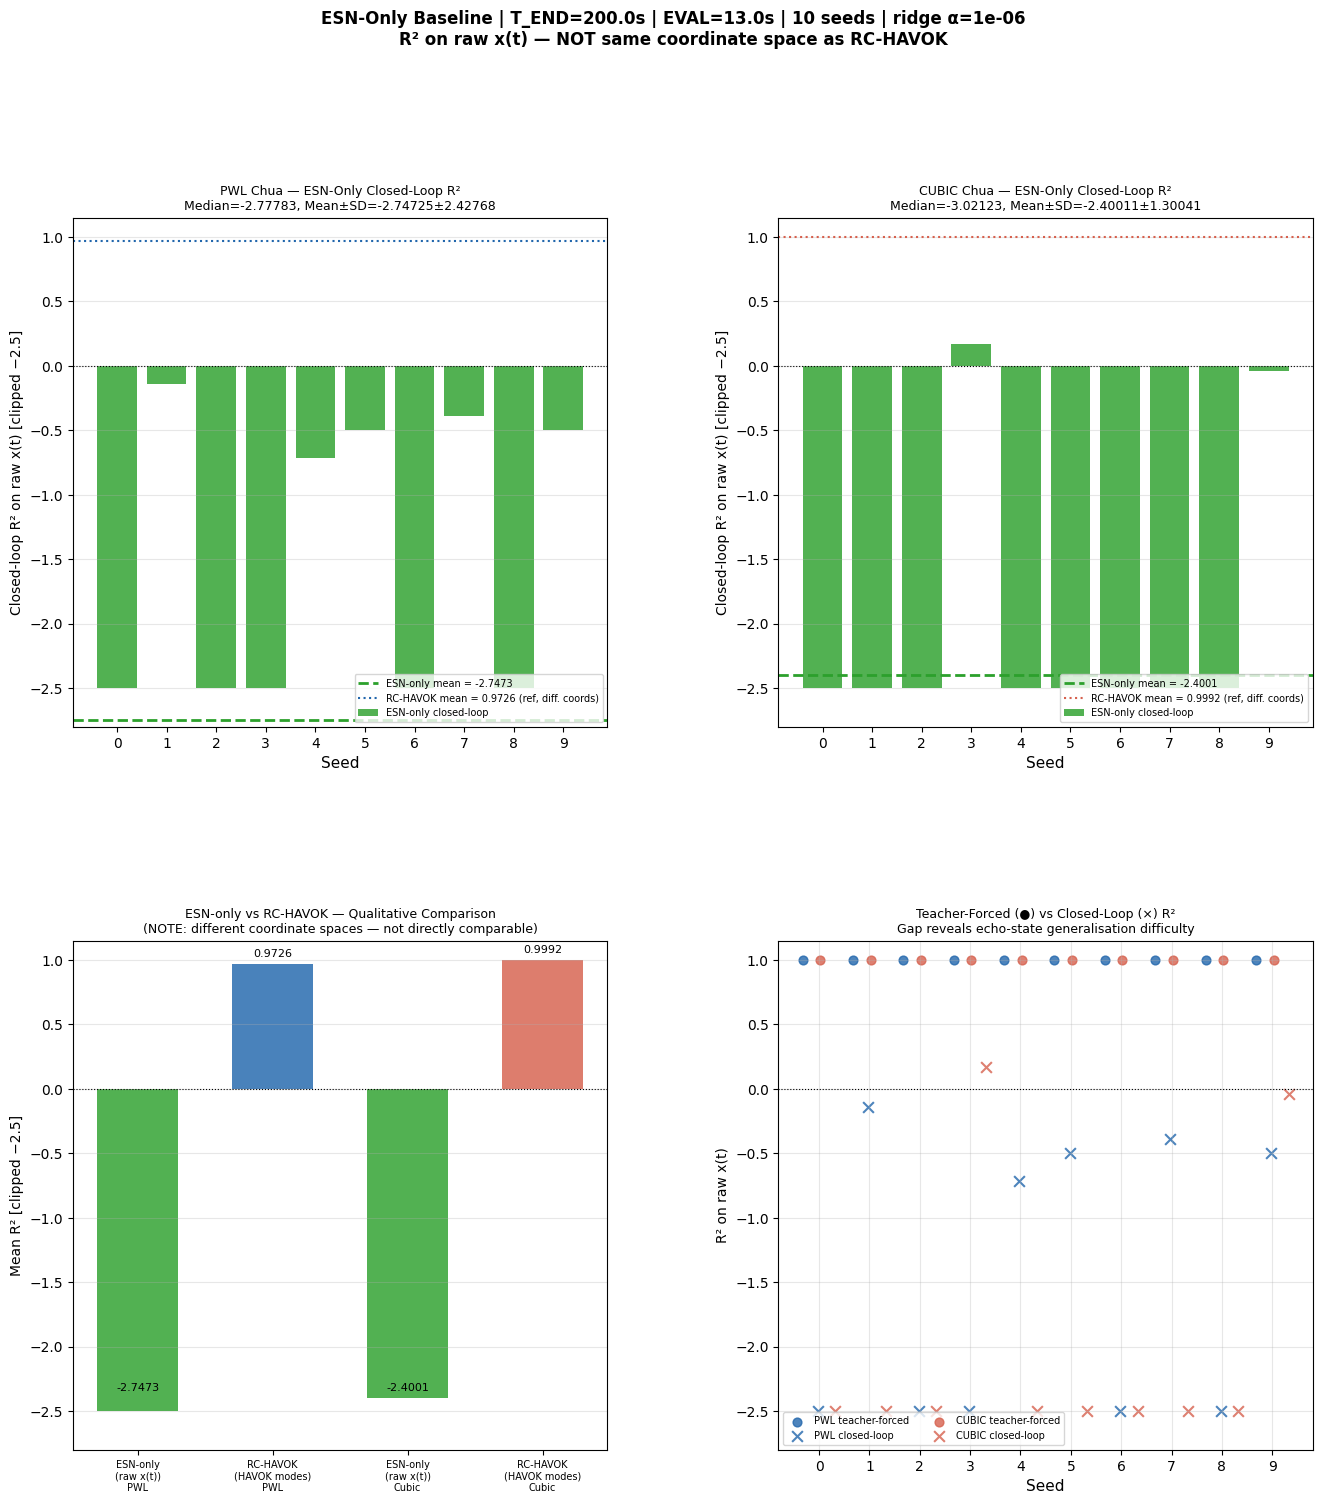

Saved: esn_only_baseline.png


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — PLOTS
# ═══════════════════════════════════════════════════════════════════

COLOURS = {'pwl': '#2166ac', 'cubic': '#d6604d'}
ESN_COL = '#2ca02c'

fig = plt.figure(figsize=(16, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Panel 1 & 2: Per-seed closed-loop R² ────────────────────────────
for pi, system in enumerate(SYSTEMS):
    ax = fig.add_subplot(gs[0, pi])
    sub  = df[df['system']==system].sort_values('seed')
    r2s  = sub['r2_cl'].values
    s    = summary[system]
    ref  = RC_HAVOK_REF[system]

    ax.bar(SEEDS, np.clip(r2s, -2.5, 1.0),
           color=ESN_COL, alpha=0.82, label='ESN-only closed-loop')
    ax.axhline(s['r2_cl_mean'], color=ESN_COL, lw=2, ls='--',
               label=f'ESN-only mean = {s["r2_cl_mean"]:.4f}')
    ax.axhline(ref['r2_mod_mean'], color=COLOURS[system], lw=1.5, ls=':',
               label=f'RC-HAVOK mean = {ref["r2_mod_mean"]:.4f} (ref, diff. coords)')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xticks(SEEDS)
    ax.set_xlabel('Seed', fontsize=11)
    ax.set_ylabel('Closed-loop R² on raw x(t) [clipped −2.5]', fontsize=10)
    ax.set_title(f'{system.upper()} Chua — ESN-Only Closed-Loop R²\n'
                 f'Median={s["r2_cl_median"]:.5f}, Mean±SD={s["r2_cl_mean"]:.5f}'
                 f'±{s["r2_cl_sd"]:.5f}', fontsize=9)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(-2.8, 1.15)

# ── Panel 3: Summary comparison (qualitative) ────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
methods = ['ESN-only\n(raw x(t))\nPWL', 'RC-HAVOK\n(HAVOK modes)\nPWL',
           'ESN-only\n(raw x(t))\nCubic', 'RC-HAVOK\n(HAVOK modes)\nCubic']
vals   = [
    summary['pwl']['r2_cl_mean'],
    RC_HAVOK_REF['pwl']['r2_mod_mean'],
    summary['cubic']['r2_cl_mean'],
    RC_HAVOK_REF['cubic']['r2_mod_mean'],
]
colours_bar = [ESN_COL, '#2166ac', ESN_COL, '#d6604d']
bars = ax3.bar(range(4), np.clip(vals, -2.5, 1.0),
               color=colours_bar, alpha=0.82, width=0.6)
for bar, v in zip(bars, vals):
    ax3.text(bar.get_x()+bar.get_width()/2,
             max(bar.get_height(), -2.4) + 0.04,
             f'{v:.4f}', ha='center', va='bottom', fontsize=8)
ax3.axhline(0, color='k', lw=0.8, ls=':')
ax3.set_xticks(range(4))
ax3.set_xticklabels(methods, fontsize=7)
ax3.set_ylabel('Mean R² [clipped −2.5]', fontsize=10)
ax3.set_title('ESN-only vs RC-HAVOK — Qualitative Comparison\n'
              '(NOTE: different coordinate spaces — not directly comparable)',
              fontsize=9)
ax3.set_ylim(-2.8, 1.15)
ax3.grid(alpha=0.3, axis='y')

# ── Panel 4: Teacher-forced vs closed-loop R² ───────────────────────
ax4 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(N_SEEDS)
width = 0.35
for pi, system in enumerate(SYSTEMS):
    sub  = df[df['system']==system].sort_values('seed')
    r2tf = sub['r2_tf'].values
    r2cl = sub['r2_cl'].values
    offset = (pi - 0.5) * width
    ax4.scatter(x_pos + offset - 0.15, r2tf,
                marker='o', s=40, color=COLOURS[system],
                label=f'{system.upper()} teacher-forced', alpha=0.8)
    ax4.scatter(x_pos + offset + 0.15, np.clip(r2cl, -2.5, 1.0),
                marker='x', s=60, color=COLOURS[system],
                label=f'{system.upper()} closed-loop', alpha=0.8)

ax4.axhline(0, color='k', lw=0.8, ls=':')
ax4.set_xticks(x_pos)
ax4.set_xlabel('Seed', fontsize=11)
ax4.set_ylabel('R² on raw x(t)', fontsize=10)
ax4.set_title('Teacher-Forced (●) vs Closed-Loop (×) R²\n'
              'Gap reveals echo-state generalisation difficulty', fontsize=9)
ax4.legend(fontsize=7, ncol=2)
ax4.grid(alpha=0.3)
ax4.set_ylim(-2.8, 1.15)

plt.suptitle(
    f'ESN-Only Baseline | T_END={T_END}s | EVAL={EVAL_SECONDS}s | '
    f'{N_SEEDS} seeds | ridge α={RIDGE_ALPHA}\n'
    'R² on raw x(t) — NOT same coordinate space as RC-HAVOK',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('esn_only_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: esn_only_baseline.png')

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — EXCEL EXPORT
# ═══════════════════════════════════════════════════════════════════

comp_rows = []
for system in SYSTEMS:
    s   = summary[system]
    ref = RC_HAVOK_REF[system]
    comp_rows.append(dict(
        System           = system.upper(),
        Method           = 'ESN-only (closed-loop, raw x(t))',
        R2_median        = s['r2_cl_median'],
        R2_mean          = s['r2_cl_mean'],
        R2_SD            = s['r2_cl_sd'],
        RMSE_median      = s['rmse_median'],
        N_diverged       = s['n_div'],
        Coord_space      = 'raw x(t)',
    ))
    comp_rows.append(dict(
        System           = system.upper(),
        Method           = 'RC-HAVOK Modified (ref, 20 seeds)',
        R2_median        = ref['r2_mod_median'],
        R2_mean          = ref['r2_mod_mean'],
        R2_SD            = ref['r2_mod_sd'],
        RMSE_median      = ref['rmse_mod_median'],
        N_diverged       = 0,
        Coord_space      = 'HAVOK temporal modes',
    ))

with pd.ExcelWriter('RC_HAVOK_ESN_Only_Baseline.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Per_Seed_Results', index=False)
    pd.DataFrame(comp_rows).to_excel(writer, sheet_name='Comparison_Summary', index=False)

print('Saved: RC_HAVOK_ESN_Only_Baseline.xlsx')

Saved: RC_HAVOK_ESN_Only_Baseline.xlsx


In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — PAPER-READY RESULT STATEMENT
# ═══════════════════════════════════════════════════════════════════

print('=' * 70)
print('PAPER-READY RESULT STATEMENT — ESN-ONLY BASELINE')
print('=' * 70)

for system in SYSTEMS:
    s   = summary[system]
    ref = RC_HAVOK_REF[system]
    print(f'\n{system.upper()} Chua:')
    print(f'  ESN-only closed-loop R²:  '
          f'median={s["r2_cl_median"]:.5f}, '
          f'mean±SD={s["r2_cl_mean"]:.5f}±{s["r2_cl_sd"]:.5f}, '
          f'RMSE={s["rmse_median"]:.2e}, '
          f'div={s["n_div"]}/{N_SEEDS}')
    print(f'  RC-HAVOK Modified R² (ref): '
          f'median={ref["r2_mod_median"]:.5f}, '
          f'mean±SD={ref["r2_mod_mean"]:.5f}±{ref["r2_mod_sd"]:.5f}')
    print(f'  Teacher-forced R² (in-sample): {s["r2_tf_mean"]:.5f}')

print()
print('─── Narrative template ───')
print("""
To assess the contribution of the HAVOK linear model identification stage,
an ESN-only baseline was evaluated in closed-loop forecast mode. A linear
readout W_out was trained on the reservoir states from the first [T-13] seconds
(teacher-forced), then operated in closed-loop for the final 13 seconds,
with the predicted x̂(k) fed back as reservoir input at each step.

IMPORTANT COORDINATE-SPACE NOTE:
ESN-only R² is evaluated on raw x(t).
RC-HAVOK R² is evaluated on HAVOK temporal modes.
These are NOT directly comparable numerically.
The comparison characterises whether the reservoir alone can sustain
a closed-loop forecast, not whether it achieves identical R² to RC-HAVOK.

Interpretation guidance:
  If ESN-only closed-loop R² is strongly positive (> 0.5): the reservoir
    alone provides significant forecasting power. HAVOK adds linear-model
    interpretability and Koopman structure.
  If ESN-only closed-loop R² is near zero or negative: closed-loop
    feedback causes rapid divergence, suggesting the reservoir state
    alone is insufficient for autonomous forecast — and the HAVOK linear
    model provides critical stabilisation of the dynamics.

Wording reminders:
  - 'closed-loop forecast R² on raw x(t)'
  - 'coordinates differ from RC-HAVOK HAVOK temporal-mode R²'
  - 'supports' / 'suggests' — not 'proves'
  - 'bounded double-scroll-like dynamics' — not 'confirmed chaos'
  - Replace [VALUES] with actual Cell 6 numbers before manuscript use
""")

PAPER-READY RESULT STATEMENT — ESN-ONLY BASELINE

PWL Chua:
  ESN-only closed-loop R²:  median=-2.77783, mean±SD=-2.74725±2.42768, RMSE=2.17e+00, div=0/10
  RC-HAVOK Modified R² (ref): median=0.97366, mean±SD=0.97255±0.00374
  Teacher-forced R² (in-sample): 1.00000

CUBIC Chua:
  ESN-only closed-loop R²:  median=-3.02123, mean±SD=-2.40011±1.30041, RMSE=2.54e+00, div=0/10
  RC-HAVOK Modified R² (ref): median=0.99918, mean±SD=0.99918±0.00001
  Teacher-forced R² (in-sample): 1.00000

─── Narrative template ───

To assess the contribution of the HAVOK linear model identification stage,
an ESN-only baseline was evaluated in closed-loop forecast mode. A linear
readout W_out was trained on the reservoir states from the first [T-13] seconds
(teacher-forced), then operated in closed-loop for the final 13 seconds,
with the predicted x̂(k) fed back as reservoir input at each step.

IMPORTANT COORDINATE-SPACE NOTE:
ESN-only R² is evaluated on raw x(t).
RC-HAVOK R² is evaluated on HAVOK temporal mo

---
## End of Notebook

### Output files
| File | Contents |
|------|----------|
| `esn_only_baseline.png` | 4-panel figure: per-seed R², comparison bar, teacher-forced vs closed-loop |
| `RC_HAVOK_ESN_Only_Baseline.xlsx` | 2 sheets: per-seed results, comparison summary |

### Coordinate-space comparison summary
| Method | Evaluation space | R² measures |
|--------|-----------------|-------------|
| RC-HAVOK Modified | HAVOK temporal modes from reservoir Hankel | Latent Koopman mode reconstruction |
| ESN-only | Raw Chua x(t) | Direct signal forecasting |
| HAVOK-only | HAVOK temporal modes from raw x(t) Hankel | Latent Koopman mode from raw signal |

All three comparisons together (ablation + HAVOK-only + ESN-only) form the  
complete baseline comparison section (Methods §III-H).

### Expected results
- Teacher-forced R² will be high (> 0.95) — ridge regression fits training data well
- Closed-loop R² may drop significantly — error accumulation in closed loop
- If closed-loop R² ≪ teacher-forced R²: reservoir alone cannot sustain autonomous forecast
- This is the expected result and is scientifically meaningful — it shows the HAVOK  
  linear model provides structure that stabilises the free-run dynamics

### Citation
Extends: Bingol & Gunay, *Data-Driven Modeling of the Koopman-Oriented Chua Circuit Based on Reservoir Computers*, ISCAS 2025.